Vérification des données

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
#Importation de la librairie matplotlib et seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as pe

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Sélection du fichier csv</h3>
</div>

In [2]:
#Importation du fichier EdStatsCountry-Series.csv
healthcare_dataset = pd.read_csv('archive/healthcare_dataset.csv')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Analyse globale</h3>
</div>

In [3]:
#info du fichier EdStatsCountry_Series
healthcare_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

Il n'y a aucune valeur vide pour chaque ligne

In [4]:
#Afficher les 5 premieres lignes de healthcare_dataset
print(healthcare_dataset.head(5))

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306    

Nous avons une liste de patient avec leurs identifications (nom, age, genre), 
les informations médicales (groupe sanguin, la maladie contractée, docteur, hopital etc...) 
ainsi que les informations de paiement (assurance, paiement). On retrouve aussi les dates d'admissions et de départs

-------------------------
Analyse colonne name

In [5]:
# vérification de quelques noms
healthcare_dataset["Name"].unique()

array(['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', ...,
       'LiSa sIMPsoN', 'RoGER farRELl', 'kaTheRIne WeBSTer'],
      shape=(49992,), dtype=object)

In [6]:
#Vérification des doublons
healthcare_dataset["Name"].describe()

count           55500
unique          49992
top       DAvId muNoZ
freq                3
Name: Name, dtype: object

On remarque qu'il y a 49 992 noms pour 55 500 lignes et donc potentiellement des doublons

Il peut y avoir plusieurs type de doublons. 
On regarde en premier les doublons 100 % identiques (memes données sur toutes les colonnes).
On vérifie ensuite par dates d'admissions.
Enfin les incohérences d'identités (même nom mais un groupe sanguin et genre différents).

In [7]:
#Doublons 100 % identiques
doublons_stricts = healthcare_dataset.duplicated()
print(f"Nombre de lignes 100 % identiques : {doublons_stricts.sum()}\n")

Nombre de lignes 100 % identiques : 534



In [8]:
#retrait des doublons identiques
healthcare_dataset = healthcare_dataset.drop_duplicates()
healthcare_dataset["Name"].count()

np.int64(54966)

In [9]:
# Extraction des lignes en doublon pour inspection
healthcare_dataset_doublons = healthcare_dataset[healthcare_dataset.duplicated(subset=["Name"], keep=False)]

# Affichage trié par identifiant pour comparer les lignes côte à côte
healthcare_dataset_doublons_tries = healthcare_dataset_doublons.sort_values(by="Name")
print(healthcare_dataset_doublons_tries.head(10))

                 Name  Age  Gender Blood Type Medical Condition  \
54393     AARon smITh   81    Male         A-            Cancer   
17083     AARon smITh   79    Male         A-            Cancer   
54112    AAron ArCHER   49  Female         B-            Cancer   
3040     AAron ArCHER   47  Female         B-            Cancer   
40305  ABIGAiL wateRS   34  Female         O+            Asthma   
52111  ABIGAiL wateRS   35  Female         O+            Asthma   
52517  ABIgAIL tucKeR   68    Male         B+            Cancer   
2018   ABIgAIL tucKeR   66    Male         B+            Cancer   
40524        ADAM OrR   26    Male        AB-         Arthritis   
8224         ADAM OrR   36  Female         A-         Arthritis   

      Date of Admission              Doctor                   Hospital  \
54393        2019-11-21         Gina Jacobs               Weber-Warren   
17083        2019-11-21         Gina Jacobs               Weber-Warren   
54112        2021-01-10  Cynthia Villanu

On constate qu'il y a des doublons avec les mêmes données sauf les ages et des patients avec des données différentes (biometrique, médicales, financier etc...)

In [10]:
#Incohérences d'identités (Même nom, ages différents)
incoherences_age = healthcare_dataset.groupby('Name')[['Age']].nunique()
patients_incoherents_age = incoherences_age[
    (incoherences_age['Age'] > 1)
]
print("Incohérences age")
print(f"Patients avec ages différents : {len(patients_incoherents_age)}")
if not patients_incoherents_age.empty:
    print(patients_incoherents_age.head(), "\n")
else:
    print("\n")

Incohérences age
Patients avec ages différents : 4973
                Age
Name               
AARon smITh       2
AAron ArCHER      2
ABIGAiL wateRS    2
ABIgAIL tucKeR    2
ADAM OrR          2 



In [11]:
#Incohérences d'identités (Même nom, attributs fixes différents)
incoherences = healthcare_dataset.groupby('Name')[['Gender', 'Blood Type']].nunique()
patients_incoherents = incoherences[
    (incoherences['Gender'] > 1) | (incoherences['Blood Type'] > 1)
]
print("Incohérences d'identité")
print(f"Patients avec des données divergentes : {len(patients_incoherents)}")
if not patients_incoherents.empty:
    print(patients_incoherents.head(), "\n")
else:
    print("\n")

Incohérences d'identité
Patients avec des données divergentes : 7
              Gender  Blood Type
Name                            
ADAM OrR           2           2
DAniEl sMIth       1           2
DAvId muNoZ        1           2
LOrI coOK          1           2
PAUL SMith         2           2 



In [12]:
#Affichage du détail des 7 patients concernés
noms_incoherents = patients_incoherents.index
healthcare_dataset_patients_incoherents = healthcare_dataset[healthcare_dataset['Name'].isin(noms_incoherents)].sort_values('Name')

#Inspection des colonnes clés pour observer les différences
print(
    healthcare_dataset_patients_incoherents[[
        'Name',
        'Age',
        'Gender',
        'Blood Type',
        'Date of Admission',
        'Doctor',
    ]]
)

               Name  Age  Gender Blood Type Date of Admission           Doctor
8224       ADAM OrR   36  Female         A-        2020-03-16     Aaron Miller
40524      ADAM OrR   26    Male        AB-        2020-06-07  Ronald Sandoval
3589   DAniEl sMIth   39  Female         B+        2022-10-11     Mark Simmons
46057  DAniEl sMIth   62  Female         O-        2023-04-28    Sharon Tucker
2491    DAvId muNoZ   31    Male        AB+        2022-12-20    Maurice Davis
46648   DAvId muNoZ   19    Male         A-        2022-08-04   Jamie Gonzales
53672   DAvId muNoZ   28    Male        AB+        2022-12-20    Maurice Davis
3841      LOrI coOK   82    Male         A-        2021-03-30   Richard Torres
27042     LOrI coOK   64    Male         B+        2022-05-07     Isaac Steele
20122    PAUL SMith   62    Male         O+        2022-01-03      Craig Davis
40666    PAUL SMith   61  Female         A+        2022-02-10  Nichole Spencer
36015     aMy smiTh   65  Female         O-        2

Avec ces informations, on peut emettre l'hypothèse qu'il s'agit d'homonyme car les données d'identitées et date d'admissions sont toutes différentes. Je vais donc garder ces données
Point d'attention : Pour DAvId muNoZ, il faut tout de même retirer une ligne car il y a un homonyme ET un doublon d'age

In [13]:
#Chevauchements d'admissions (Même patient, même date d'admission)
cols_sejour = ['Name', 'Date of Admission']
doublons_sejour = healthcare_dataset.duplicated(subset=cols_sejour, keep=False)
lignes_chevauchement = healthcare_dataset[doublons_sejour]
print("Chevauchements d'admission")
print(f"Patients admis plusieurs fois le même jour : {lignes_chevauchement['Name'].nunique()}")

Chevauchements d'admission
Patients admis plusieurs fois le même jour : 4966


Avec toutes ces informations, les 4966 lignes avec le même jour d'admission correspondent aux 4973 patients avec un age différent en retirant les homonymes. On peut émettre l'hypothèse d'une duplication des patients avec une variation de l'age seulement. Je vais donc garder une ligne de ces patients en supprimant les doulons 

In [14]:
#Suppressions
cols_admission = ['Name', 'Date of Admission', 'Doctor', 'Hospital', 'Billing Amount']
healthcare_dataset = healthcare_dataset.drop_duplicates(subset=cols_admission, keep='first')
print(f"Nombre de lignes restantes : {len(healthcare_dataset)}")

Nombre de lignes restantes : 50000


In [15]:
#Vérification pour le patient DAvId muNoZ
print(healthcare_dataset.query('Name == "DAvId muNoZ"'))

              Name  Age Gender Blood Type Medical Condition Date of Admission  \
2491   DAvId muNoZ   31   Male        AB+          Diabetes        2022-12-20   
46648  DAvId muNoZ   19   Male         A-            Cancer        2022-08-04   

               Doctor      Hospital Insurance Provider  Billing Amount  \
2491    Maurice Davis   Wall-Weaver           Medicare    25773.328236   
46648  Jamie Gonzales  Olsen-Thomas         Blue Cross    32454.950609   

       Room Number Admission Type Discharge Date  Medication  Test Results  
2491           406       Elective     2023-01-09  Penicillin  Inconclusive  
46648          406         Urgent     2022-08-17     Aspirin  Inconclusive  


Conclusion des doublons : 

Les doublons identiques et les doublons où seul l'age diverge ont été retiré. 
les doublons avec age, groupe sanguin, et genre sont gardés pour etre dans l'hypothèse de l'homonymie.

Point d'attention pour le métier : Il faut vérifier l'age de chaque patient qui avait l'age en doublon car cela reste une information importante pour le suivi médical

-----------------------------------
Analyse colonne age

In [16]:
healthcare_dataset["Age"].describe()

count    50000.000000
mean        51.580360
std         19.582194
min         18.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         85.000000
Name: Age, dtype: float64

On retrouve des ages cohérents sans valeur aberrante

-----------------------------------
Analyse colonne Gender 

In [17]:
print(healthcare_dataset["Gender"].describe())
print(healthcare_dataset["Gender"].unique())

count      50000
unique         2
top       Female
freq       25011
Name: Gender, dtype: object
['Male' 'Female']


On retrouve les 2 genres sur l'ensemble des patients

-----------------------------------
Analyse colonne Blood Type 

In [18]:
print(healthcare_dataset["Blood Type"].describe())
print(healthcare_dataset["Blood Type"].unique())

count     50000
unique        8
top         AB+
freq       6291
Name: Blood Type, dtype: object
['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']


On retrouve les 8 groupes sanguins connus

-----------------------------------
Analyse colonne Medical Condition

In [19]:
print(healthcare_dataset["Medical Condition"].describe())
print(healthcare_dataset["Medical Condition"].unique())

count         50000
unique            6
top       Arthritis
freq           8439
Name: Medical Condition, dtype: object
['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']


On retrouve les 6 maladies connues

-----------------------------------
Analyse colonne Date of Admission et Discharge Date

In [20]:
print(healthcare_dataset["Date of Admission"].describe())
print(healthcare_dataset["Date of Admission"].unique())

count          50000
unique          1827
top       2024-03-16
freq              45
Name: Date of Admission, dtype: object
['2024-01-31' '2019-08-20' '2022-09-22' ... '2019-05-31' '2023-10-12'
 '2021-03-14']


In [21]:
print(healthcare_dataset["Discharge Date"].describe())
print(healthcare_dataset["Discharge Date"].unique())

count          50000
unique          1856
top       2020-03-15
freq              45
Name: Discharge Date, dtype: object
['2024-02-02' '2019-08-26' '2022-10-07' ... '2019-05-09' '2024-05-31'
 '2024-06-06']


In [22]:
#Vérification du format des dates

# Colonnes contenant des dates dans ton DataFrame
cols_dates = ['Date of Admission', 'Discharge Date']

# Regex pour le format AAAA-MM-JJ (ex: 2021-01-17)
pattern_date = r'^\d{4}-\d{2}-\d{2}$'

for col in cols_dates:
  # Vérification du format texte avec Regex
  format_valide = healthcare_dataset[col].astype(str).str.match(pattern_date)
  nb_invalides = (~format_valide).sum()

  # Tentative de conversion pour vérifier la validité des dates (ex: exclure 2023-02-31)
  dates_converties = pd.to_datetime(healthcare_dataset[col], format='%Y-%m-%d', errors='coerce')
  nb_dates_impossibles = dates_converties.isna().sum()

  print(f'--- Analyse de la colonne : {col} ---')
  print(f'Formats incorrects (Regex) : {nb_invalides}')
  print(f'Dates invalides ou impossibles : {nb_dates_impossibles}\n')

  if nb_invalides > 0 or nb_dates_impossibles > 0:
    print(f'Lignes problématiques dans {col} :')
    print(healthcare_dataset[~format_valide | dates_converties.isna()][col].head())

--- Analyse de la colonne : Date of Admission ---
Formats incorrects (Regex) : 0
Dates invalides ou impossibles : 0

--- Analyse de la colonne : Discharge Date ---
Formats incorrects (Regex) : 0
Dates invalides ou impossibles : 0



-----------------------------------
Analyse colonne Billing Amount

In [23]:
print(healthcare_dataset["Billing Amount"].describe())

count    50000.000000
mean     25555.691557
std      14215.932247
min      -2008.492140
25%      13239.403094
50%      25541.302839
75%      37853.996819
max      52764.276736
Name: Billing Amount, dtype: float64


Il existe des montants négatifs. Je réalise l'analyse pour savoir à quoi cela correspond

In [24]:
# 1. Isolation des montants négatifs
montants_negatifs = healthcare_dataset[healthcare_dataset['Billing Amount'] < 0]

print(f"Nombre de montants négatifs : {len(montants_negatifs)}")
print(
    f"Pourcentage du dataset :"
    f" {(len(montants_negatifs) / len(healthcare_dataset)) * 100:.2f}%\n"
)

# 2. Aperçu des lignes concernées
print("--- Aperçu des valeurs négatives ---")
print(
    montants_negatifs.head(10)
)

# 3. Statistiques comparatives
print("\n--- Statistiques des montants négatifs ---")
print(montants_negatifs['Billing Amount'].describe())

Nombre de montants négatifs : 96
Pourcentage du dataset : 0.19%

--- Aperçu des valeurs négatives ---
                          Name  Age  Gender Blood Type Medical Condition  \
132            ashLEy ERIcKSoN   32  Female        AB-            Cancer   
799          CHRisTOPHer wEiss   49  Female        AB-            Asthma   
1018             AsHley WaRnER   60    Male         A+      Hypertension   
1421              JAY galloWaY   74  Female         O+            Asthma   
2103         josHUa wilLIamSon   72  Female         B-          Diabetes   
2696             Scott VaZqUEz   74    Male         B+          Diabetes   
2855            CaROl aNDErSoN   39  Female         B-      Hypertension   
3772  mr. ChRIStOPhER aLvARaDO   77    Male        AB+           Obesity   
5445            ALExAndrA KHaN   32    Male        AB+         Arthritis   
5708                JosEPh cOx   23    Male        AB-          Diabetes   

     Date of Admission               Doctor                  

In [25]:
#Analyse de la colonne Test Results
montants_negatifs["Test Results"].unique()

array(['Normal', 'Inconclusive', 'Abnormal'], dtype=object)

In [26]:
#vérification de Test Results si on retire tous les montants négatifs du dataset 
healthcare_dataset_sans_montant_negatif = healthcare_dataset[healthcare_dataset['Billing Amount'] > 0]
healthcare_dataset_sans_montant_negatif["Test Results"].unique()

array(['Normal', 'Inconclusive', 'Abnormal'], dtype=object)

In [27]:
#Calcul des bornes et détection des outliers (méthode IQR)
Q1 = healthcare_dataset["Billing Amount"].quantile(0.25)
Q3 = healthcare_dataset["Billing Amount"].quantile(0.75)
IQR = Q3 - Q1

borne_inferieure = Q1 - 1.5 * IQR
borne_superieure = Q3 + 1.5 * IQR

# Isolation des outliers
outliers = healthcare_dataset[
    (healthcare_dataset["Billing Amount"] < borne_inferieure)
    | (healthcare_dataset["Billing Amount"] > borne_superieure)
]

print("--- Analyse des Outliers (Billing Amount) ---")
print(f"Borne inférieure (sous la moustache) : {borne_inferieure:.2f} €")
print(f"Borne supérieure (au-dessus de la moustache) : {borne_superieure:.2f} €")
print(f"Nombre total d'outliers détectés : {len(outliers)}")

--- Analyse des Outliers (Billing Amount) ---
Borne inférieure (sous la moustache) : -23682.49 €
Borne supérieure (au-dessus de la moustache) : 74775.89 €
Nombre total d'outliers détectés : 0


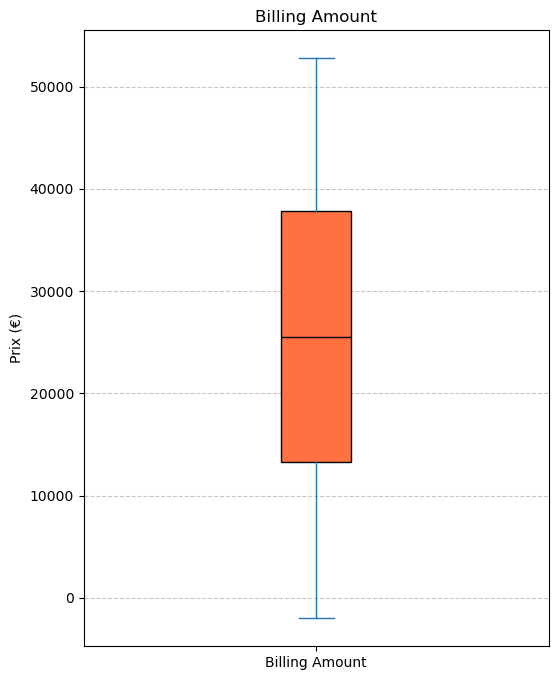

In [28]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
plt.figure(figsize=(6, 8))
healthcare_dataset['Billing Amount'].plot.box(
    patch_artist=True,
    boxprops=dict(facecolor='#FF7140'),
    medianprops=dict(color='black')
)
plt.title("Billing Amount")
plt.ylabel("Prix (€)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Avec ces informations et une analyse IQR classique, on constate que l'on pourrait avoir des montant négatifs assez important (jusqu'à -23 682 €). Dans l'hypothèse métiers où ces montants négatifs sont des remboursements, On pourrait avoir des montants négatifs important (remboursement à 20, 30%). Or le montant maximum négatif est d'environ - 2 008 €
De plus, le nombre de montants négatifs (96) qui représente 0.19% du dataset n'est pas cohérent avec le nombre de remboursement que peut y avoir.

Vérifions maintenant si les montants négatifs sont associés à un montant positif (donc un paiement initial avant remboursement)

In [29]:
#Filtrage pour ne garder que les groupes de doublons qui contiennent AU MOINS une valeur négative
noms_avec_negatifs = healthcare_dataset_doublons[healthcare_dataset_doublons['Billing Amount'] < 0]['Name'].unique()
doublons_avec_negatifs = healthcare_dataset_doublons[healthcare_dataset_doublons['Name'].isin(noms_avec_negatifs)].sort_values(by=['Name', 'Date of Admission'])

print(f"Nombre total de lignes de doublons avec au moins un montant négatif :"f" {len(doublons_avec_negatifs)}")

if not doublons_avec_negatifs.empty:
  print('\nVoici les lignes concernées :')
  display(doublons_avec_negatifs)
else:
  print("\nPas de montant négatif")

Nombre total de lignes de doublons avec au moins un montant négatif : 20

Voici les lignes concernées :


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
53204,AsHley WaRnER,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
43392,DR. micHaEl MckAy,67,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal
54136,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal
14534,LiSA rOBInSoN,29,Female,B-,Arthritis,2022-12-29,Nancy Thompson,Chandler PLC,Cigna,-26.112523,198,Emergency,2023-01-12,Penicillin,Normal
50369,LiSA rOBInSoN,33,Female,B-,Arthritis,2022-12-29,Nancy Thompson,Chandler PLC,Cigna,-26.112523,198,Emergency,2023-01-12,Penicillin,Normal
25907,MAtThew siMMons,47,Female,A-,Cancer,2023-06-03,Jacob Russo,Smith Group,Aetna,-68.319621,288,Emergency,2023-06-20,Ibuprofen,Normal
52095,MAtThew siMMons,43,Female,A-,Cancer,2023-06-03,Jacob Russo,Smith Group,Aetna,-68.319621,288,Emergency,2023-06-20,Ibuprofen,Normal
34243,dAnIel dRaKe,67,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal
53232,dAnIel dRaKe,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal


Conclusion montant négatifs : 

Après analyse, Ces données négative ne sont pas concidéré comme Outlier. Magré tout je ne vais pas prendre en compte ces données car : 

Il n'y a aucun historique de facturation lié : Pour un remboursement, il devrait exister une facture initiale positive (ex. +15 000) suivie d'une ligne d'ajustement (-15 000) pour le même séjour ou la même admission. Ici, la ligne négative est la seule et unique trace de l'hospitalisation du patient.

De plus, Aucun statut ou type d'opération associé : La colonne Admission Type pour ces lignes indique des entrées normales (Emergency, Elective, Urgent) et le champ Test Results affiche des résultats médicaux normaux. Il n'y a aucun champ de transaction (par exemple remboursement, crédit etc...)

-----------------------------------
Analyse répartition des données

In [30]:
# Comptage du nombre de lignes par assureur
nombre_patients_par_assureur = (
    healthcare_dataset["Insurance Provider"].value_counts().reset_index())
nombre_patients_par_assureur.columns = ["Assurance", "Nombre de patients"]

print(nombre_patients_par_assureur)

          Assurance  Nombre de patients
0             Cigna               10091
1          Medicare               10058
2  UnitedHealthcare               10002
3        Blue Cross               10001
4             Aetna                9848


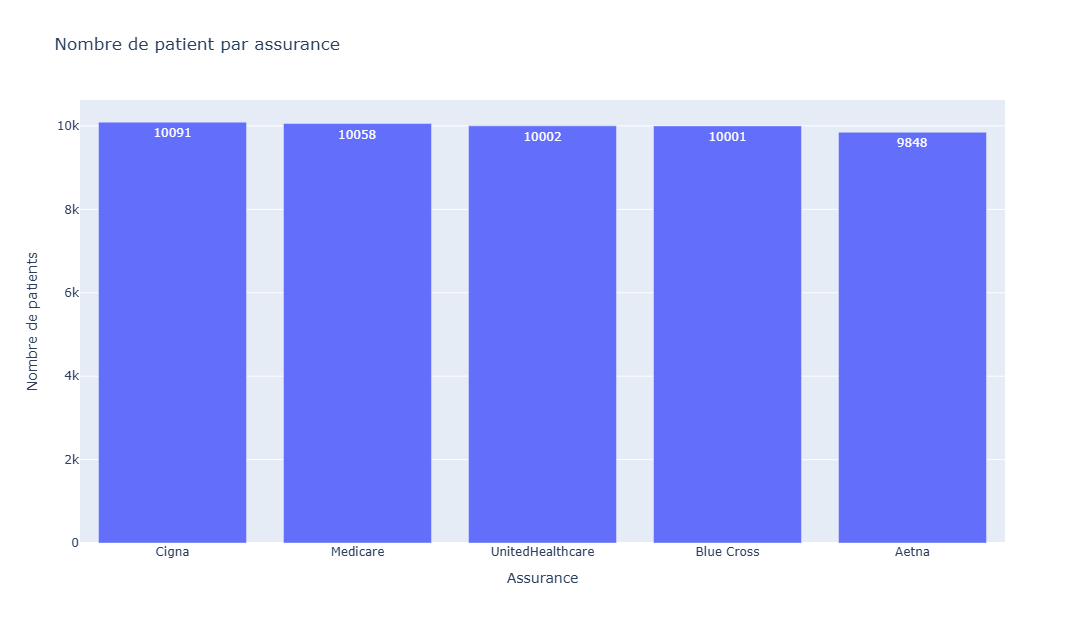

In [31]:
#Graphique en barre du nombre de patients par assurances 
nombre_patients_par_assureur_graphique = pe.bar(
    nombre_patients_par_assureur,
    x          = 'Assurance',
    y          = 'Nombre de patients',          
    text       = 'Nombre de patients',             # affiche directement la valeur
    title      = "Nombre de patient par assurance",
    height     = 600,
    width      = 1100
)

nombre_patients_par_assureur_graphique.show()

In [32]:
# Comptage du nombre de lignes par pathologie
nombre_patients_par_pathologie = (
    healthcare_dataset["Medical Condition"].value_counts().reset_index())
nombre_patients_par_pathologie.columns = ["Pathologie", "Nombre de patients"]

print(nombre_patients_par_pathologie)

     Pathologie  Nombre de patients
0     Arthritis                8439
1      Diabetes                8384
2  Hypertension                8319
3        Cancer                8294
4       Obesity                8292
5        Asthma                8272


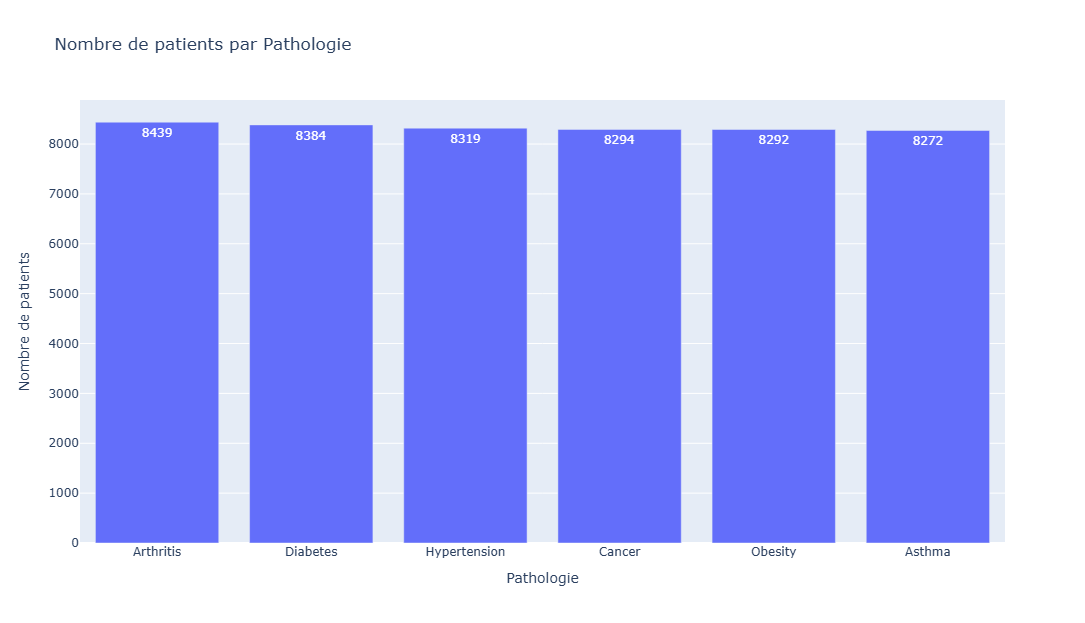

In [33]:
#Graphique en barre du nombre de patients par pathologie 
nombre_patients_par_pathologie_graphique = pe.bar(
    nombre_patients_par_pathologie,
    x          = 'Pathologie',
    y          = 'Nombre de patients',          
    text       = 'Nombre de patients',             # affiche directement la valeur
    title      = "Nombre de patients par Pathologie",
    height     = 600,
    width      = 1100
)

nombre_patients_par_pathologie_graphique.show()

Conclusion analyse répartition des données : 
Les données sont homogènes, il n'y a pas de de grande variation dans la répartition des données 